# Analisis Regresi Linear: Probabilitas Hujan vs ONI
**Dashboard Probabilitas Hujan NTT — 1985–2015**

Notebook ini mereproduksi analisis regresi dan korelasi yang sama persis dengan Tab 3 (Korelasi) di Streamlit dashboard.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

## 1. Konfigurasi (sama persis dengan app.py)

In [2]:
# ── Konfigurasi musim — identik dengan app.py ──
SEASON_ORDER  = ['JFM', 'AMJ', 'JAS', 'OND']
SEASON_COLORS = {
    'JFM': '#3b82f6',
    'AMJ': '#22c55e',
    'JAS': '#eab308',
    'OND': '#ec4899',
}
SEASON_MONTHS = {
    'JFM': 'Jan–Mar',
    'AMJ': 'Apr–Jun',
    'JAS': 'Jul–Sep',
    'OND': 'Okt–Des',
}

## 2. Load Data

In [3]:
# ── Load spasial_data.csv ──
# Ganti path sesuai lokasi file Anda
try:
    spasial = pd.read_csv('spasial_data.csv')
    spasial.columns = spasial.columns.str.strip()
    # Normalise nama kolom (sama dengan app.py)
    for c in spasial.columns:
        if c.lower() in ('season', 'musim'):
            spasial.rename(columns={c: 'Season'}, inplace=True)
    for c in spasial.columns:
        if c.lower() in ('hujan', 'rain', 'prob', 'probability'):
            spasial.rename(columns={c: 'Hujan'}, inplace=True)
    spasial['Season'] = spasial['Season'].str.upper().str.strip()
    print(f'Spasial loaded: {spasial.shape}')
    print(spasial.head())
except FileNotFoundError:
    # Fallback data simulasi — identik dengan app.py
    print('File tidak ditemukan, menggunakan data simulasi...')
    rng  = np.random.default_rng(42)
    lats = np.linspace(-12, -7, 25)
    lons = np.linspace(118, 126, 25)
    rows = []
    for y in range(1985, 2016):
        for s in SEASON_ORDER:
            for la in lats:
                for lo in lons:
                    base = 40 + 30 * np.sin(np.radians((lo - 118) * 20))
                    rows.append({'Year': y, 'Season': s,
                                 'latitude': la, 'longitude': lo,
                                 'Hujan': float(np.clip(base + rng.normal(0, 15), 0, 100))})
    spasial = pd.DataFrame(rows)

Spasial loaded: (57660, 5)
   Year Season  latitude  longitude      Hujan
0  1985    AMJ     -11.5     118.00  61.538462
1  1985    AMJ     -11.5     118.25  53.846154
2  1985    AMJ     -11.5     118.50  53.846154
3  1985    AMJ     -11.5     118.75  54.945055
4  1985    AMJ     -11.5     119.00  56.043956


In [4]:
# ── Load ONI.csv ──
try:
    oni = pd.read_csv('ONI.csv')
    oni.columns = oni.columns.str.strip()
    oni = oni[(oni['Year'] >= 1985) & (oni['Year'] <= 2015)]
    cols_keep = [c for c in ['Year', 'JFM', 'AMJ', 'JAS', 'OND'] if c in oni.columns]
    oni = oni[cols_keep]
    print(f'ONI loaded: {oni.shape}')
    print(oni.head())
except FileNotFoundError:
    # Fallback data simulasi — identik dengan app.py
    print('ONI.csv tidak ditemukan, menggunakan data simulasi...')
    rng   = np.random.default_rng(7)
    years = np.arange(1985, 2016)
    oni   = pd.DataFrame({
        'Year': years,
        'JFM':  rng.normal(0, 0.7, len(years)),
        'AMJ':  rng.normal(0, 0.7, len(years)),
        'JAS':  rng.normal(0, 0.7, len(years)),
        'OND':  rng.normal(0, 0.7, len(years)),
    })

ONI loaded: (31, 5)
    Year  JFM  AMJ  JAS  OND
35  1985 -0.7 -0.7 -0.4 -0.2
36  1986 -0.4 -0.1  0.4  1.0
37  1987  1.2  0.9  1.6  1.2
38  1988  0.5 -0.8 -1.1 -1.7
39  1989 -1.4 -0.6 -0.3 -0.2


## 3. Fungsi Helper (identik dengan app.py)

In [5]:
def build_rainfall_timeseries(spasial):
    """Mean probabilitas hujan per Year × Season — identik dengan app.py."""
    ts = (
        spasial.groupby(['Year', 'Season'])['Hujan']
        .mean()
        .reset_index()
        .pivot(index='Year', columns='Season', values='Hujan')
        .reindex(columns=SEASON_ORDER)
        .reset_index()
    )
    return ts


def build_corr_df(spasial, oni):
    """
    Merge spatial mean dengan ONI untuk korelasi.
    Output kolom: Year, CH_JFM, CH_AMJ, CH_JAS, CH_OND,
                        ONI_JFM, ONI_AMJ, ONI_JAS, ONI_OND
    Identik dengan app.py.
    """
    ts = build_rainfall_timeseries(spasial)

    ch_rename  = {s: f'CH_{s}'  for s in SEASON_ORDER if s in ts.columns}
    oni_rename = {s: f'ONI_{s}' for s in SEASON_ORDER if s in oni.columns}

    ts_renamed  = ts.rename(columns=ch_rename)
    oni_renamed = oni.rename(columns=oni_rename)

    merged = ts_renamed.merge(oni_renamed, on='Year', how='inner')
    return merged


# Bangun dataframe korelasi
corr_df  = build_corr_df(spasial, oni)
num_cols = [c for c in corr_df.columns if c != 'Year']
corr_mat = corr_df[num_cols].corr()

print('Kolom corr_df:', corr_df.columns.tolist())
print(corr_df.head())

Kolom corr_df: ['Year', 'CH_JFM', 'CH_AMJ', 'CH_JAS', 'CH_OND', 'ONI_JFM', 'ONI_AMJ', 'ONI_JAS', 'ONI_OND']
   Year     CH_JFM     CH_AMJ     CH_JAS     CH_OND  ONI_JFM  ONI_AMJ  \
0  1985  82.372760  56.915987  30.867228  58.031791     -0.7     -0.7   
1  1986  89.240143  59.385561  46.998597  53.398784     -0.4     -0.1   
2  1987  84.470729  52.520383  35.133240  61.425900      1.2      0.9   
3  1988  86.014416  40.985466  31.262272  65.123890      0.5     -0.8   
4  1989  88.074074  61.599905  31.958859  47.781674     -1.4     -0.6   

   ONI_JAS  ONI_OND  
0     -0.4     -0.2  
1      0.4      1.0  
2      1.6      1.2  
3     -1.1     -1.7  
4     -0.3     -0.2  


## 4. Heatmap Korelasi Lengkap (Tab 3 — Heatmap Full)

In [6]:
fig_heat_full = px.imshow(
    corr_mat,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    aspect='auto',
    title='Heatmap Korelasi (CH × ONI)',
)
fig_heat_full.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    title_font=dict(size=14, color='#0f3460'),
    coloraxis_colorbar=dict(title='r', tickfont=dict(size=10)),
    height=500,
    margin=dict(l=20, r=20, t=55, b=20),
    xaxis=dict(tickangle=-35),
)
fig_heat_full.update_traces(textfont_size=11)
fig_heat_full.show()

## 5. Heatmap Korelasi Parsial CH vs ONI per Musim

In [7]:
ch_cols  = [c for c in num_cols if c.startswith('CH_')]
oni_cols = [c for c in num_cols if c.startswith('ONI_')]
partial_corr = corr_df[ch_cols + oni_cols].corr().loc[ch_cols, oni_cols]

print('Matriks Korelasi Parsial CH vs ONI:')
print(partial_corr.round(3))

fig_partial = px.imshow(
    partial_corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    labels=dict(x='ONI Season', y='Curah Hujan Season', color='r'),
    title='Korelasi Curah Hujan vs ONI per Musim',
)
fig_partial.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    title_font=dict(size=13, color='#0f3460'),
    height=380,
    margin=dict(l=20, r=20, t=50, b=20),
)
fig_partial.update_traces(textfont_size=13)
fig_partial.show()

Matriks Korelasi Parsial CH vs ONI:
        ONI_JFM  ONI_AMJ  ONI_JAS  ONI_OND
CH_JFM   -0.444   -0.419   -0.295   -0.266
CH_AMJ    0.054    0.036   -0.269   -0.245
CH_JAS    0.496    0.311   -0.157   -0.144
CH_OND    0.134   -0.352   -0.673   -0.783


## 6. Regresi Linear: Scatter Plot CH vs ONI per Musim

**Variabel:**
- **X (prediktor):** `ONI_{musim}` — nilai Oceanic Niño Index
- **Y (respons):** `CH_{musim}` — probabilitas hujan rata-rata (%)

Regresi menggunakan `np.polyfit(x, y, 1)` — identik dengan app.py.

In [8]:
valid_seasons = [s for s in SEASON_ORDER
                 if f'CH_{s}' in corr_df.columns and f'ONI_{s}' in corr_df.columns]
n = len(valid_seasons)

fig_sc = make_subplots(
    rows=1, cols=n,
    subplot_titles=[f'{s} ({SEASON_MONTHS[s]})' for s in valid_seasons]
)

# Tabel ringkasan regresi
reg_summary = []

for i, s in enumerate(valid_seasons, 1):
    x_data = corr_df[f'ONI_{s}']
    y_data = corr_df[f'CH_{s}']
    color  = SEASON_COLORS[s]

    # ── Regresi Linear (identik dengan app.py) ──
    mask = x_data.notna() & y_data.notna()
    if mask.sum() > 2:
        coef   = np.polyfit(x_data[mask], y_data[mask], 1)  # [slope, intercept]
        x_line = np.linspace(x_data.min(), x_data.max(), 50)
        y_line = np.polyval(coef, x_line)
        r_val  = np.corrcoef(x_data[mask], y_data[mask])[0, 1]

        reg_summary.append({
            'Musim': s,
            'Slope (b1)': round(coef[0], 4),
            'Intercept (b0)': round(coef[1], 4),
            'r (Pearson)': round(r_val, 4),
            'r² (R-squared)': round(r_val**2, 4),
            'n': int(mask.sum()),
        })

        # Garis regresi
        fig_sc.add_trace(
            go.Scatter(x=x_line, y=y_line, mode='lines',
                       line=dict(color=color, width=2, dash='dash'),
                       name=f'Trend {s}', showlegend=False),
            row=1, col=i
        )
        # Label r
        fig_sc.add_annotation(
            x=x_data.max(), y=y_data.max(),
            text=f'r={r_val:.2f}',
            showarrow=False, font=dict(size=11, color=color),
            xref=f'x{i}', yref=f'y{i}'
        )

    # Scatter points
    fig_sc.add_trace(
        go.Scatter(
            x=x_data, y=y_data,
            mode='markers',
            marker=dict(color=color, size=7, opacity=0.75,
                        line=dict(color='white', width=1)),
            text=corr_df['Year'],
            hovertemplate='Tahun: %{text}<br>ONI: %{x:.2f}<br>CH: %{y:.1f}%<extra></extra>',
            name=s, showlegend=False
        ),
        row=1, col=i
    )
    fig_sc.update_xaxes(title_text='ONI', row=1, col=i, gridcolor='#eee')
    fig_sc.update_yaxes(title_text='Prob. Hujan (%)' if i == 1 else '',
                        row=1, col=i, gridcolor='#eee')

fig_sc.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    height=360,
    margin=dict(l=55, r=20, t=50, b=50),
    title=dict(text='Scatter: Probabilitas Hujan vs ONI per Musim',
               font=dict(size=14, color='#0f3460'))
)
fig_sc.show()

## 7. Tabel Ringkasan Hasil Regresi

In [9]:
df_reg = pd.DataFrame(reg_summary)
print('=== Ringkasan Regresi Linear: CH ~ ONI per Musim ===')
print(df_reg.to_string(index=False))

# Tampilkan dengan styling di Jupyter
df_reg.style.background_gradient(
    subset=['r (Pearson)', 'r² (R-squared)'],
    cmap='RdBu_r', vmin=-1, vmax=1
).format({
    'Slope (b1)': '{:.4f}',
    'Intercept (b0)': '{:.4f}',
    'r (Pearson)': '{:.4f}',
    'r² (R-squared)': '{:.4f}',
})

=== Ringkasan Regresi Linear: CH ~ ONI per Musim ===
Musim  Slope (b1)  Intercept (b0)  r (Pearson)  r² (R-squared)  n
  JFM     -1.8531         85.1727      -0.4442          0.1973 31
  AMJ      0.5612         56.4589       0.0360          0.0013 31
  JAS     -1.5811         32.7445      -0.1569          0.0246 31
  OND     -7.1122         58.4537      -0.7834          0.6137 31


,Musim,Slope (b1),Intercept (b0),r (Pearson),r² (R-squared),n
0,JFM,-1.8531,85.1727,-0.4442,0.1973,31
1,AMJ,0.5612,56.4589,0.0360,0.0013,31
2,JAS,-1.5811,32.7445,-0.1569,0.0246,31
3,OND,-7.1122,58.4537,-0.7834,0.6137,31


## 8. (Opsional) Versi Matplotlib untuk Laporan/Export
Cocok untuk disimpan ke PNG/PDF di laporan.

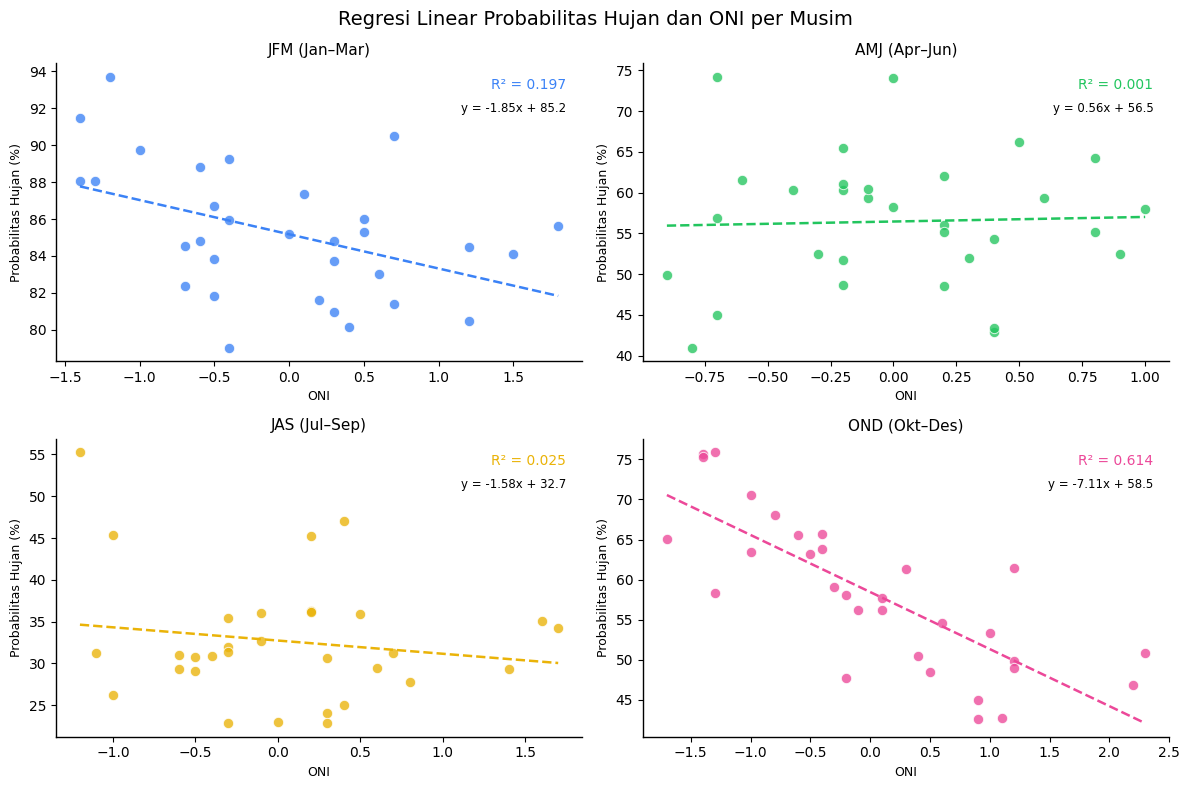

In [21]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    facecolor='white'
)

axes = axes.flatten()

for ax, s in zip(axes, valid_seasons):

    x_data = corr_df[f'ONI_{s}'].values
    y_data = corr_df[f'CH_{s}'].values
    color  = SEASON_COLORS[s]

    mask = ~np.isnan(x_data) & ~np.isnan(y_data)

    # ======================================
    # SCATTER PLOT
    # ======================================
    ax.scatter(
        x_data[mask],
        y_data[mask],
        color=color,
        alpha=0.78,
        edgecolors='white',
        linewidths=0.7,
        s=55,
        zorder=3
    )

    # ======================================
    # REGRESI LINEAR
    # ======================================
    if mask.sum() > 2:

        coef = np.polyfit(
            x_data[mask],
            y_data[mask],
            1
        )

        x_line = np.linspace(
            x_data[mask].min(),
            x_data[mask].max(),
            50
        )

        y_line = np.polyval(coef, x_line)

        # Korelasi & R²
        r_val = np.corrcoef(
            x_data[mask],
            y_data[mask]
        )[0, 1]

        r_squared = r_val**2

        # Garis regresi
        ax.plot(
            x_line,
            y_line,
            color=color,
            linewidth=1.8,
            linestyle='--',
            zorder=4
        )

        # Nilai R²
        ax.text(
            0.97, 0.95,
            f'R² = {r_squared:.3f}',
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=10,
            color=color
        )

        # Persamaan garis
        ax.text(
            0.97, 0.87,
            f'y = {coef[0]:.2f}x + {coef[1]:.1f}',
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=8.5,
            color='black'
        )

    # ======================================
    # JUDUL SUBPLOT
    # ======================================
    ax.set_title(
        f'{s} ({SEASON_MONTHS[s]})',
        fontsize=11,
        color='black'
    )

    # ======================================
    # LABEL AXIS
    # ======================================
    ax.set_xlabel(
        'ONI',
        fontsize=9
    )

    ax.set_ylabel(
        'Probabilitas Hujan (%)',
        fontsize=9
    )

    # ======================================
    # STYLE PPKI
    # ======================================
    ax.set_facecolor('white')

    # Hilangkan garis atas & kanan
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Tebalkan garis kiri & bawah
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)

    # Hilangkan grid
    ax.grid(False)

# ======================================
# HAPUS SUBPLOT KOSONG
# ======================================
for i in range(len(valid_seasons), 4):
    fig.delaxes(axes[i])

# ======================================
# JUDUL UTAMA
# ======================================
fig.suptitle(
    'Regresi Linear Probabilitas Hujan dan ONI per Musim',
    fontsize=14,
    color='black',
    y=0.98
)

plt.tight_layout()

plt.show()

## 9. Time Series Probabilitas Hujan per Musim (Tab 2)

Visualisasi time series rerata probabilitas hujan per musim (1985–2015), identik dengan Tab 2 di Streamlit dashboard.

In [22]:
ts_df = build_rainfall_timeseries(spasial)

# ======================================
# TIME SERIES CURAH HUJAN
# FORMAT PPKI IPB EDISI 4
# ======================================

fig_ts = go.Figure()

for s in SEASON_ORDER:

    col_name = s

    if col_name in ts_df.columns:

        fig_ts.add_trace(
            go.Scatter(
                x=ts_df['Year'],
                y=ts_df[col_name],

                name=f'{s} ({SEASON_MONTHS[s]})',

                line=dict(
                    color=SEASON_COLORS[s],
                    width=2.2
                ),

                mode='lines+markers',

                marker=dict(
                    size=5
                ),

                hovertemplate=(
                    f'<b>{s}</b><br>' +
                    'Tahun: %{x}<br>' +
                    'Probabilitas: %{y:.1f}%<extra></extra>'
                )
            )
        )

# ======================================
# LAYOUT
# ======================================
fig_ts.update_layout(

    title=dict(
        text='Probabilitas Hujan Rerata per Musim (1985–2015)',
        x=0.5,

        font=dict(
            family='Times New Roman',
            size=15,
            color='black'
        )
    ),

    font=dict(
        family='Times New Roman',
        size=12,
        color='black'
    ),

    plot_bgcolor='white',
    paper_bgcolor='white',

    width=950,
    height=420,

    margin=dict(
        l=70,
        r=40,
        t=60,
        b=60
    ),

    hovermode='x unified',

    legend=dict(
        orientation='h',
        y=1.05,
        x=0.5,
        xanchor='center'
    )
)

# ======================================
# X AXIS
# ======================================
fig_ts.update_xaxes(

    title='Tahun',

    showgrid=False,

    showline=True,
    linewidth=1,
    linecolor='black',

    ticks='outside',
    tickwidth=1,
    tickcolor='black'
)

# ======================================
# Y AXIS
# ======================================
fig_ts.update_yaxes(

    title='Probabilitas Hujan (%)',

    range=[0, 100],

    showgrid=False,

    showline=True,
    linewidth=1,
    linecolor='black',

    ticks='outside',
    tickwidth=1,
    tickcolor='black'
)

fig_ts.show()

## 10. Time Series Indeks ONI per Musim (Tab 2)

Visualisasi Oceanic Niño Index (ONI) per musim dengan zona El Niño dan La Niña, identik dengan Tab 2.

In [12]:
fig_oni = go.Figure()
for s in SEASON_ORDER:
    if s in oni.columns:
        fig_oni.add_trace(go.Scatter(
            x=oni['Year'], y=oni[s],
            name=f"ONI {s}",
            line=dict(color=SEASON_COLORS[s], width=2),
            mode='lines+markers',
            marker=dict(size=4),
            hovertemplate=f'<b>ONI {s}</b><br>Tahun: %{{x}}<br>ONI: %{{y:.2f}}<extra></extra>'
        ))

# El Niño / La Niña bands
fig_oni.add_hrect(y0=0.5, y1=3.5, fillcolor='rgba(239,68,68,0.08)',
                  annotation_text="El Niño", annotation_position="top right",
                  annotation_font_color='#dc2626', line_width=0)
fig_oni.add_hrect(y0=-3.5, y1=-0.5, fillcolor='rgba(59,130,246,0.08)',
                  annotation_text="La Niña", annotation_position="bottom right",
                  annotation_font_color='#2563eb', line_width=0)
fig_oni.add_hline(y=0, line_dash='dash', line_color='#999', line_width=1)

fig_oni.update_layout(
    title=dict(text='Indeks ONI per Musim (1985–2015)',
               font=dict(size=15, color='#0f3460'), x=0.01),
    xaxis=dict(title='Tahun', showgrid=True, gridcolor='#eee'),
    yaxis=dict(title='ONI Index', showgrid=True, gridcolor='#eee'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    height=360,
    margin=dict(l=60, r=20, t=60, b=50),
    hovermode='x unified'
)
fig_oni.show()


## 11. Dual-Axis: Probabilitas Hujan vs ONI per Musim (Tab 2)

Grafik dual-axis yang menampilkan bar chart probabilitas hujan dan line chart ONI secara bersamaan untuk setiap musim.

In [20]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ==============================
# STYLE PPKI IPB EDISI 4
# ==============================
PPKI_LIGHTBLUE = '#4ea8de'
PPKI_RED       = '#c1121f'
PPKI_FONT      = 'Times New Roman'

for sel_season in SEASON_ORDER:

    if sel_season not in ts_df.columns or sel_season not in oni.columns:
        continue

    merged_view = ts_df[['Year', sel_season]].merge(
        oni[['Year', sel_season]],
        on='Year',
        suffixes=('_CH', '_ONI')
    )

    fig_dual = make_subplots(
        specs=[[{"secondary_y": True}]]
    )

    # ======================================
    # BAR HUJAN
    # ======================================
    fig_dual.add_trace(
        go.Bar(
            x=merged_view['Year'],
            y=merged_view[f'{sel_season}_CH'],
            name='Probabilitas Hujan',
            marker_color=PPKI_LIGHTBLUE,
            marker_line_width=0,
            opacity=0.82,
            hovertemplate=(
                '<b>Tahun</b>: %{x}<br>' +
                '<b>Probabilitas</b>: %{y:.1f}%<extra></extra>'
            )
        ),
        secondary_y=False
    )

    # ======================================
    # GARIS ONI
    # ======================================
    fig_dual.add_trace(
        go.Scatter(
            x=merged_view['Year'],
            y=merged_view[f'{sel_season}_ONI'],
            name='ONI',
            mode='lines+markers',
            line=dict(
                color=PPKI_RED,
                width=2.2
            ),
            marker=dict(size=5),
            hovertemplate=(
                '<b>Tahun</b>: %{x}<br>' +
                '<b>ONI</b>: %{y:.2f}<extra></extra>'
            )
        ),
        secondary_y=True
    )

    # ======================================
    # LAYOUT
    # ======================================
    fig_dual.update_layout(

        title=dict(
            text=f'Hubungan Probabilitas Hujan dan ONI Musim {sel_season}',
            x=0.5,
            font=dict(
                family=PPKI_FONT,
                size=15,
                color='black'
            )
        ),

        font=dict(
            family=PPKI_FONT,
            size=12,
            color='black'
        ),

        plot_bgcolor='white',
        paper_bgcolor='white',

        width=950,
        height=420,

        margin=dict(
            l=70,
            r=70,
            t=60,
            b=60
        ),

        hovermode='x unified',

        legend=dict(
            orientation='h',
            y=1.05,
            x=0.5,
            xanchor='center'
        )
    )

    # ======================================
    # X AXIS
    # ======================================
    fig_dual.update_xaxes(
        title_text='Tahun',
        showline=True,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        showgrid=False
    )

    # ======================================
    # Y AXIS KIRI
    # ======================================
    fig_dual.update_yaxes(
        title_text='Probabilitas Hujan (%)',
        secondary_y=False,
        showgrid=False,
        zeroline=False,
        showline=True,
        linewidth=1,
        linecolor='black',
        ticks='outside'
    )

    # ======================================
    # Y AXIS KANAN
    # ======================================
    fig_dual.update_yaxes(
        title_text='ONI',
        secondary_y=True,
        showgrid=False,
        zeroline=False,
        showline=True,
        linewidth=1,
        linecolor='black',
        ticks='outside'
    )

    fig_dual.show()

In [13]:
from plotly.subplots import make_subplots

for sel_season in SEASON_ORDER:
    if sel_season not in ts_df.columns or sel_season not in oni.columns:
        continue

    merged_view = ts_df[['Year', sel_season]].merge(
        oni[['Year', sel_season]], on='Year', suffixes=('_CH', '_ONI')
    )

    fig_dual = make_subplots(specs=[[{"secondary_y": True}]])
    fig_dual.add_trace(
        go.Bar(x=merged_view['Year'],
               y=merged_view[f'{sel_season}_CH'],
               name='Prob. Hujan (%)',
               marker_color='rgba(26,111,168,0.55)',
               marker_line=dict(width=0),
               hovertemplate='Prob: %{y:.1f}%<extra></extra>'),
        secondary_y=False
    )
    fig_dual.add_trace(
        go.Scatter(x=merged_view['Year'],
                   y=merged_view[f'{sel_season}_ONI'],
                   name='ONI Index',
                   line=dict(color='#ef4444', width=2.5),
                   mode='lines+markers',
                   marker=dict(size=5),
                   hovertemplate='ONI: %{y:.2f}<extra></extra>'),
        secondary_y=True
    )
    fig_dual.update_layout(
        title=dict(
            text=f'Probabilitas Hujan vs ONI — {sel_season} ({SEASON_MONTHS[sel_season]})',
            font=dict(size=14, color='#0f3460'), x=0.01),
        plot_bgcolor='white', paper_bgcolor='white',
        height=340,
        margin=dict(l=60, r=60, t=55, b=50),
        legend=dict(orientation='h', y=1.1, x=0.5, xanchor='center'),
        hovermode='x unified'
    )
    fig_dual.update_yaxes(title_text='Probabilitas Hujan (%)',
                          secondary_y=False, gridcolor='#eee')
    fig_dual.update_yaxes(title_text='ONI Index', secondary_y=True)
    fig_dual.show()


## 12. Distribusi Musiman — Radar Chart & Box Plot (Tab 4)

Visualisasi distribusi probabilitas hujan per musim menggunakan Radar Chart dan Box Plot.

In [14]:
ts_df2 = build_rainfall_timeseries(spasial)
season_means = {s: ts_df2[s].mean() for s in SEASON_ORDER if s in ts_df2.columns}

# ── Radar Chart ──
categories = list(season_means.keys())
values     = list(season_means.values())
values_closed = values + [values[0]]
cats_closed   = categories + [categories[0]]

fig_radar = go.Figure()
fig_radar.add_trace(go.Scatterpolar(
    r=values_closed,
    theta=cats_closed,
    fill='toself',
    fillcolor='rgba(26,111,168,0.18)',
    line=dict(color='#1a6fa8', width=2.5),
    marker=dict(size=9, color='#1a6fa8'),
    name='Rerata CH (%)'
))
fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 100],
                        gridcolor='#ddd', tickfont=dict(size=9)),
        angularaxis=dict(gridcolor='#ddd')
    ),
    showlegend=False,
    title=dict(text='Probabilitas Hujan Rerata per Musim (Radar)',
               font=dict(size=13, color='#0f3460'), x=0.5, xanchor='center'),
    paper_bgcolor='white',
    height=420,
    margin=dict(l=40, r=40, t=55, b=40)
)
fig_radar.show()

# ── Box Plot ──
fig_box = go.Figure()
for s in SEASON_ORDER:
    if s in ts_df2.columns:
        fig_box.add_trace(go.Box(
            y=ts_df2[s],
            name=f"{s} ({SEASON_MONTHS[s]})",
            marker_color=SEASON_COLORS[s],
            boxmean='sd',
            hovertemplate=f'<b>{s}</b><br>%{{y:.1f}}%<extra></extra>'
        ))
fig_box.update_layout(
    title=dict(text='Distribusi Probabilitas Hujan per Musim (Box Plot)',
               font=dict(size=13, color='#0f3460'), x=0.5, xanchor='center'),
    yaxis=dict(title='Probabilitas Hujan (%)', range=[0, 100], gridcolor='#eee'),
    plot_bgcolor='white', paper_bgcolor='white',
    showlegend=False,
    height=380,
    margin=dict(l=55, r=20, t=55, b=50)
)
fig_box.show()


## 13. Stacked Bar — Persentase Hujan per Musim Tiap Tahun (Tab 4)

Diagram batang bertumpuk yang menunjukkan kontribusi persentase setiap musim terhadap total probabilitas hujan tahunan.

In [15]:
avail_s = [s for s in SEASON_ORDER if s in ts_df2.columns]
row_sums = ts_df2[avail_s].sum(axis=1)
pct_df = ts_df2[['Year']].copy()
for s in avail_s:
    pct_df[s] = ts_df2[s] / row_sums * 100

fig_stack = go.Figure()
for s in avail_s:
    fig_stack.add_trace(go.Bar(
        x=pct_df['Year'],
        y=pct_df[s],
        name=f'{s} ({SEASON_MONTHS[s]})',
        marker_color=SEASON_COLORS[s],
        hovertemplate=f'<b>{s}</b><br>Tahun: %{{x}}<br>Porsi: %{{y:.1f}}%<extra></extra>'
    ))

fig_stack.update_layout(
    barmode='stack',
    title=dict(text='Persentase Kontribusi Hujan per Musim (1985–2015)',
               font=dict(size=14, color='#0f3460'), x=0.01),
    xaxis=dict(title='Tahun', showgrid=False),
    yaxis=dict(title='Persentase (%)', range=[0, 100], gridcolor='#eee'),
    plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    height=380,
    margin=dict(l=60, r=20, t=60, b=50),
    hovermode='x unified'
)
fig_stack.show()


## 14. Violin Plot — Distribusi Full per Musim (Tab 4)

Violin plot yang menampilkan distribusi lengkap probabilitas hujan dari seluruh grid point per musim (1985–2015).

In [16]:
fig_viol = go.Figure()
for s in SEASON_ORDER:
    if s in spasial['Season'].unique():
        vals = spasial[spasial['Season'] == s]['Hujan'].dropna().values
        fig_viol.add_trace(go.Violin(
            y=vals,
            name=f'{s} ({SEASON_MONTHS[s]})',
            box_visible=True,
            meanline_visible=True,
            fillcolor=SEASON_COLORS[s],
            opacity=0.7,
            line_color=SEASON_COLORS[s],
            hovertemplate=f'<b>{s}</b><br>%{{y:.1f}}%<extra></extra>'
        ))
fig_viol.update_layout(
    title=dict(text='Distribusi Probabilitas Hujan per Grid & Musim (1985–2015)',
               font=dict(size=14, color='#0f3460'), x=0.01),
    yaxis=dict(title='Probabilitas Hujan (%)', gridcolor='#eee'),
    plot_bgcolor='white', paper_bgcolor='white',
    showlegend=False,
    height=400,
    margin=dict(l=60, r=20, t=55, b=50)
)
fig_viol.show()
